# Publication styles

`x4c.set_style()` accepts `journal`, `nature`, `agu`, `web`, `presentation`, `dark`
and `minimal`, with `_grid`/`_nogrid` and `_spines`/`_nospines` modifiers.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
ts_path = os.path.join(
    case_dir, 'atm', 'proc', 'tseries', 'month_1',
    f'{casename}.cam.h0.TS.000101-000512.nc',
)
ds = x4c.open_dataset(ts_path, comp='atm', grid='ne16np4', vn='TS', shift_time=True)
gmst = ds.x.da.x.annualize().x.gm

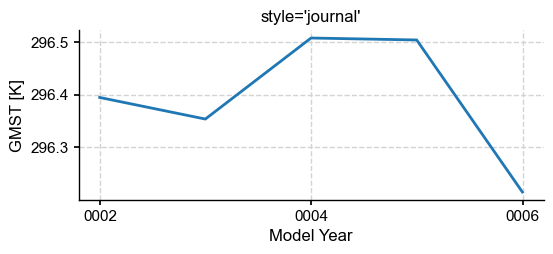

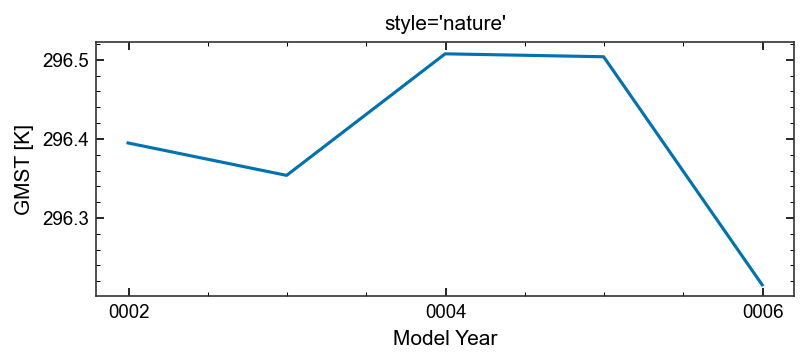

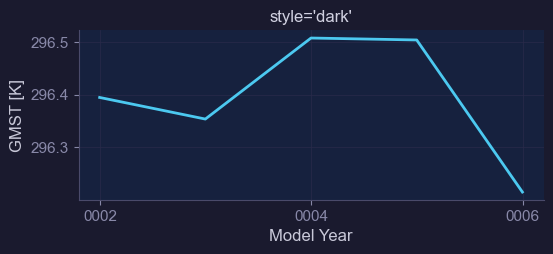

In [3]:
for style in ['journal', 'nature', 'dark']:
    x4c.set_style(style)
    fig, ax = gmst.x.plot(figsize=(6, 2.2))
    ax.set(title=f"style='{style}'", ylabel='GMST [K]')
    x4c.showfig(fig)

x4c.set_style('journal')  # restore